# Credit Score Classification — Data Exploration & Modeling

**Context.** Data scientist at a financial institution scoring customer credit
performance. Target: `Credit_Score` ∈ {Good, Standard, Poor}.

This notebook covers the required points:
1. Features used
2. Preprocessing performed
3. Machine-learning models tried
4. Evaluation metric and why
5. Experiments run to find the best model

The reusable cleaning / training logic lives in `src/preprocessing.py` and
`src/train.py` (OOP). This notebook explains and explores; the `.py` files are
the production pipeline.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
sys.path.insert(0, 'src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

DATA = 'data_C.csv' if os.path.exists('data_C.csv') else '../data_C.csv'
df = pd.read_csv(DATA, index_col=0)
print(df.shape)
df.head()

(25000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.0,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,9,10,1663,2,"Personal Loan, and Student Loan",58,14,15.53,6.0,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,1,6,2,1,Auto Loan,25,4,5.04,1.0,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,3,7,5,0,NaN,30,15,24.73,6.0,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,4,1405,14,6,"Auto Loan, Payday Loan, Student Loan, Auto Loa...",30,19,16.44,7.0,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


## 1. First look — the data is deliberately dirty

Notice three pathologies that drive every preprocessing decision:
- Numeric columns stored as strings with trailing `_` (e.g. `28_`, `43534.9_`).
- Placeholder garbage in categoricals (`_______`, `!@9#%8`, `_`, `__10000__`).
- `Credit_History_Age` as free text: `"9 Years and 8 Months"`.
- Impossible outliers injected as noise (Age in the thousands, negative loans).

In [2]:
print('Dtypes (many numerics are object = dirty):')
print(df.dtypes)
print('\nTarget distribution (IMBALANCED):')
print(df['Credit_Score'].value_counts(normalize=True).round(3))

Dtypes (many numerics are object = dirty):
ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance      

In [3]:
# Evidence of contamination
for c in ['Age','Annual_Income','Num_of_Loan','Outstanding_Debt']:
    bad = df[c].astype(str).str.contains('_', na=False).sum()
    print(f'{c}: {bad} values contain "_"')
print('\nOccupation placeholder _______ count:',
      (df['Occupation']=='_______').sum())
print('Payment_Behaviour junk !@9#%8 count:',
      (df['Payment_Behaviour']=='!@9#%8').sum())
print('Credit_Mix junk _ count:', (df['Credit_Mix']=='_').sum())

Age: 1245 values contain "_"
Annual_Income: 1778 values contain "_"
Num_of_Loan: 1204 values contain "_"
Outstanding_Debt: 270 values contain "_"

Occupation placeholder _______ count: 1765
Payment_Behaviour junk !@9#%8 count: 1951
Credit_Mix junk _ count: 4926


In [4]:
# Raw numeric ranges AFTER stripping underscores -> impossible values
age = pd.to_numeric(df['Age'].astype(str).str.replace('_',''), errors='coerce')
ir = df['Interest_Rate']
print('Age range:', age.min(), 'to', age.max(), '(should be ~14-95)')
print('Interest_Rate max:', ir.max(), '(should be < 50)')
nloan = pd.to_numeric(df['Num_of_Loan'].astype(str).str.replace('_',''), errors='coerce')
print('Num_of_Loan range:', nloan.min(), 'to', nloan.max())

Age range: -500 to 8697 (should be ~14-95)
Interest_Rate max: 5797 (should be < 50)
Num_of_Loan range: -100 to 1495


### The leakage trap: customers repeat across rows

25,000 rows but far fewer unique customers — each appears in ~8 monthly
records. A naive random `train_test_split` puts the **same customer in train and
test**, letting the model memorize per-customer patterns and report an inflated
score. We must split **by `Customer_ID`** (GroupShuffleSplit).

In [5]:
print('Rows:', len(df))
print('Unique customers:', df['Customer_ID'].nunique())
print('Avg rows per customer:', round(len(df)/df['Customer_ID'].nunique(),2))

Rows: 25000
Unique customers: 11254
Avg rows per customer: 2.22


## 2. Preprocessing (implemented in `DataCleaner`)

Steps, applied identically at train and inference time because `DataCleaner` is
a transformer baked into the pickled pipeline:

1. **`Credit_History_Age`**: parse `"X Years and Y Months"` → total months.
2. **Underscore strip + numeric coercion** for the dirty numeric-string columns.
3. **Outlier clipping**: values outside plausible ranges → NaN.
4. **Placeholder → NaN** for categorical junk tokens.
5. **`Type_of_Loan`** free text → binary "has loan detail" flag.
6. **Drop identifiers** (`ID`, `Customer_ID`, `Name`, `SSN`, `Month`) — leakage.

Then a `ColumnTransformer`: median-impute + standardize numerics; mode-impute +
one-hot encode categoricals.

In [6]:
from preprocessing import DataCleaner, PreprocessorBuilder, TARGET
cleaned = DataCleaner().transform(df.drop(columns=[TARGET]))
print('After cleaning — dtypes are now proper numerics/categoricals:')
print(cleaned.dtypes)
print('\nRemaining NaNs (will be imputed in the pipeline):')
print(cleaned.isnull().sum()[cleaned.isnull().sum()>0])

After cleaning — dtypes are now proper numerics/categoricals:
Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Type_of_Loan                  int64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
dtype: object

Remaining NaNs (will be imputed in the pipeline):
Age                         701
Occupation                 1765
Annual_Income    

In [7]:
# Feature lists the model will use
pb = PreprocessorBuilder.from_cleaned_frame(cleaned.assign(**{TARGET:'x'}))
print('NUMERIC features:', pb.numeric_cols)
print('\nCATEGORICAL features:', pb.categorical_cols)

NUMERIC features: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']

CATEGORICAL features: ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


### Quick EDA: how features relate to the target

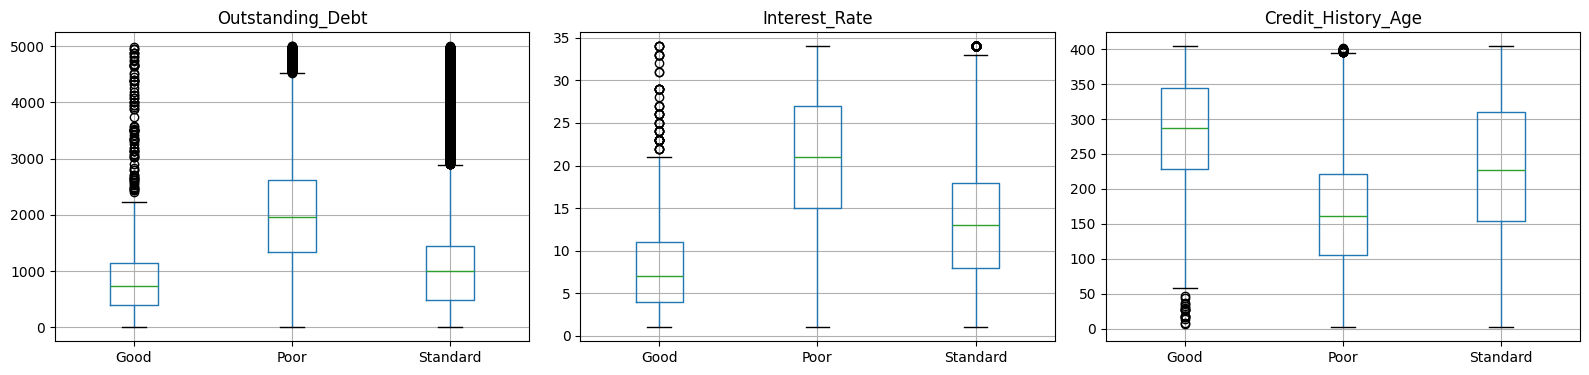

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
clean_full = cleaned.copy(); clean_full[TARGET] = df[TARGET].values
for ax, col in zip(axes, ['Outstanding_Debt','Interest_Rate','Credit_History_Age']):
    clean_full.boxplot(column=col, by=TARGET, ax=ax)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle(''); plt.tight_layout(); plt.show()

In [9]:
# Credit_Mix is highly predictive — sanity check
pd.crosstab(clean_full['Credit_Mix'], clean_full[TARGET], normalize='index').round(2)

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,0.01,0.60,0.38
Good,0.49,0.15,0.35
Standard,0.05,0.22,0.73


## 3 & 4. Models and metric

**Models tried** (all inside the same clean→preprocess→model pipeline):
- Logistic Regression — linear baseline.
- Random Forest — non-linear, handles mixed features.
- XGBoost — gradient boosting.
- LightGBM — gradient boosting, fast.

**Metric: macro-F1.** Accuracy is misleading here because the classes are
imbalanced (Standard ≈ 53%) — a model can score well on accuracy while failing
the minority `Good` class. Macro-F1 averages F1 across classes equally, so it
penalizes ignoring minorities. We also report accuracy for context.

## 5. Experiment — run the full training pipeline

This calls the production `ModelTrainer`, which trains all four models, logs
every run to **MLflow**, and saves the best by macro-F1. Open the MLflow UI with
`mlflow ui` to compare runs.

In [10]:
from train import ModelTrainer
trainer = ModelTrainer(data_path=DATA, model_dir='models'
                       if os.path.exists('data_C.csv') else '../models')
metadata = trainer.run()
metadata['leaderboard']

2026/06/07 17:02:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/07 17:02:38 INFO mlflow.store.db.utils: Updating database tables


2026/06/07 17:02:39 INFO mlflow.tracking.fluent: Experiment with name 'credit_score_classification' does not exist. Creating a new experiment.


2026/06/07 17:02:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LogisticRegression] macro-F1=0.6547 acc=0.6597


...

2026/06/07 17:02:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[XGBoost           ] macro-F1=0.6543 acc=0.6833


2026/06/07 17:03:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LightGBM          ] macro-F1=0.6819 acc=0.6909

BEST: LightGBM  macro-F1=0.6819
              precision    recall  f1-score   support

        Good       0.55      0.76      0.64       909
        Poor       0.67      0.72      0.69      1457
    Standard       0.79      0.65      0.71      2645

    accuracy                           0.69      5011
   macro avg       0.67      0.71      0.68      5011
weighted avg       0.71      0.69      0.69      5011



{'LogisticRegression': 0.654740480178574,
 'RandomForest': 0.6678123838406758,
 'XGBoost': 0.6543112918989968,
 'LightGBM': 0.6819459362020358}

### Results & interpretation

LightGBM gives the best macro-F1 (~0.68) under the **honest grouped split**.

> Note: with a naive random split the same numbers jump to ~0.80+, but that is
> leakage — the score does not generalize to unseen customers. The grouped
> split is the defensible methodology.

The best pipeline is saved to `models/model.pkl` and consumed by
`src/inference.py` and the Streamlit app.

In [11]:
# Confirm the saved artifact predicts correctly on a held example
from inference import InferencePipeline
mdir = 'models' if os.path.exists('data_C.csv') else '../models'
pipe = InferencePipeline(model_dir=mdir)
sample = df.drop(columns=[TARGET]).iloc[0].to_dict()
print('Prediction for first row:', pipe.predict_with_confidence(sample)[0])

Prediction for first row: {'prediction': 'Poor', 'confidence': 0.8044, 'probabilities': {'Good': 0.0018, 'Poor': 0.8044, 'Standard': 0.1938}}
